In [1]:
import pandas as pd
import numpy as np
import requests 
import seaborn as sns
import matplotlib.pyplot as plt

## Introduction

This project investigates the relationship between population growth and GDP per capita across countries from 1960 to 2021. Population data from Kaggle and GDP-per-capita data from the World Bank API will be gathered, assessed, cleaned, combined, and analyzed to answer the research question: **How are population growth and GDP per capita related across countries between 1960 and 2021?**

#### **Dataset 1**

Type: *CSV FILE* 

Method: *Population dataset downloaded manually as a csv file from Kaggle, it contains annual population figures for different countries.*

Dataset variables:

*   *Variable 1 Country Name*
*   *Variable 2 Country Code*

In [3]:
#1st data gathering and loading method

df = pd.read_csv("Downloads/World-population-by-countries-dataset.csv")
df.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,54208.0,55434.0,56234.0,56699.0,57029.0,57357.0,57702.0,58044.0,...,102565.0,103165.0,103776.0,104339.0,104865.0,105361.0,105846.0,106310.0,106766.0,107195.0
1,Africa Eastern and Southern,AFE,130836765.0,134159786.0,137614644.0,141202036.0,144920186.0,148769974.0,152752671.0,156876454.0,...,547482863.0,562601578.0,578075373.0,593871847.0,609978946.0,626392880.0,643090131.0,660046272.0,677243299.0,694665117.0
2,Afghanistan,AFG,8996967.0,9169406.0,9351442.0,9543200.0,9744772.0,9956318.0,10174840.0,10399936.0,...,31161378.0,32269592.0,33370804.0,34413603.0,35383028.0,36296111.0,37171922.0,38041757.0,38928341.0,39835428.0
3,Africa Western and Central,AFW,96396419.0,98407221.0,100506960.0,102691339.0,104953470.0,107289875.0,109701811.0,112195950.0,...,370243017.0,380437896.0,390882979.0,401586651.0,412551299.0,423769930.0,435229381.0,446911598.0,458803476.0,470898870.0
4,Angola,AGO,5454938.0,5531451.0,5608499.0,5679409.0,5734995.0,5770573.0,5781305.0,5774440.0,...,25107925.0,26015786.0,26941773.0,27884380.0,28842482.0,29816769.0,30809787.0,31825299.0,32866268.0,33933611.0


#### Dataset 2

Type: *JSON FILE* 

Method: *GDP per capita dataset gathered programmatically from the world bank API using pythons requests library*

Dataset variables:

*   *Variable 1 country*
*   *Variable 2 country_code*
*   *Variable 3 year*
*   *Variable 4 gdp_per_capitay*

In [5]:
#2nd data gathering and loading method

url = ("https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD")
params = {
    "date": "1960:2021",
    "format": "json",
    "per_page": 20000
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

api_result = response.json()

#The first item contains API metadata; the second contains observations
records = api_result[1]

gdp_df = pd.DataFrame([
    {"country": record["country"]["value"],
    "country_code": record["countryiso3code"],
    "year": record["date"], 
    "gdp_per_capita": record["value"]}
    for record in records
])

gdp_df.head()

,country,country_code,year,gdp_per_capita
0,Africa Eastern and Southern,AFE,2021,1560.894626
1,Africa Eastern and Southern,AFE,2020,1351.503167
2,Africa Eastern and Southern,AFE,2019,1508.031525
3,Africa Eastern and Southern,AFE,2018,1553.617944
4,Africa Eastern and Southern,AFE,2017,1529.923080


## 2. Assess data

### Quality Issue 1:

In [6]:
#Inspecting the dataframe visually
gdp_df.sample(20)

#This directly shows where values are missing.

,country,country_code,year,gdp_per_capita
15212,Tunisia,TUN,1999,2376.065668
495,East Asia & Pacific (excluding high income),EAP,1960,90.278502
7716,Greece,GRC,1993,10257.308579
15954,Vanuatu,VUT,2001,1350.183382
6396,Dominica,DMA,2011,7705.407172
11272,Morocco,MAR,1971,279.167236
9124,Jordan,JOR,2011,4363.428002
2647,South Asia (IDA & IBRD),TSA,1978,201.526092
1864,"Middle East, North Africa, Afghanistan & Pakis...",MNA,2017,2865.835156
8082,Guinea-Bissau,GNB,1999,478.733191


In [7]:
 #Inspecting the dataframe programmatically
gdp_df["gdp_per_capita"].isna().sum()

#This accurately counts all missing values in each column.

2672

Issue and justification: *Completness issue: Missing GDP Values - some country records have missing gdp values, this will result into biased comparisons*

### Quality Issue 2:

In [8]:
#Inspecting the dataframe visually
gdp_df[["country", "country_code"]].drop_duplicates().head(30)

#This helps identify obvious non-country entries such as “World” and “High income”.

,country,country_code
0,Africa Eastern and Southern,AFE
62,Africa Western and Central,AFW
124,Arab World,ARB
186,Caribbean small states,CSS
248,Central Europe and the Baltics,CEB
310,Early-demographic dividend,EAR
372,East Asia & Pacific,EAS
434,East Asia & Pacific (excluding high income),EAP
496,East Asia & Pacific (IDA & IBRD countries),TEA
558,Euro area,EMU


In [9]:
#Inspecting the dataframe programmatically

#Retriving World banks official metadata.
country_data = requests.get("https://api.worldbank.org/v2/country", params={"format":"json", "per_page":400}).json()[1]

valid_codes = {
    country["id"]
    for country in country_data
    if country["region"]["id"] != "NA"
}

In [10]:
#Find Invalid aggregate entries
invalid_gdp_entries = gdp_df[~gdp_df["country_code"].isin(valid_codes)]

invalid_gdp_entries[["country", "country_code"]].drop_duplicates()

#This systematically identifies every regional or income-group aggregate

,country,country_code
0,Africa Eastern and Southern,AFE
62,Africa Western and Central,AFW
124,Arab World,ARB
186,Caribbean small states,CSS
248,Central Europe and the Baltics,CEB
310,Early-demographic dividend,EAR
372,East Asia & Pacific,EAS
434,East Asia & Pacific (excluding high income),EAP
496,East Asia & Pacific (IDA & IBRD countries),TEA
558,Euro area,EMU


In [11]:
#Programmatic Assesment of Population dataset
invalid_population_entries = df[~df["Country Code"].isin(valid_codes)]
invalid_population_entries[["Country Name", "Country Code"]].drop_duplicates()

,Country Name,Country Code
1,Africa Eastern and Southern,AFE
3,Africa Western and Central,AFW
7,Arab World,ARB
36,Central Europe and the Baltics,CEB
49,Caribbean small states,CSS
61,East Asia & Pacific (excluding high income),EAP
62,Early-demographic dividend,EAR
63,East Asia & Pacific,EAS
64,Europe & Central Asia (excluding high income),ECA
65,Europe & Central Asia,ECS


Issue and justification: *Validity issue: Aggregate mixed with countries - Entries such as "world", "High income" are there alongside individual countries including them could cause double counting.*

### Tidiness Issue 1:

In [12]:
#Inspecting the dataframe visually
df.head()

#This clearly shows that years are column headers rather than values in a year column

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,54208.0,55434.0,56234.0,56699.0,57029.0,57357.0,57702.0,58044.0,...,102565.0,103165.0,103776.0,104339.0,104865.0,105361.0,105846.0,106310.0,106766.0,107195.0
1,Africa Eastern and Southern,AFE,130836765.0,134159786.0,137614644.0,141202036.0,144920186.0,148769974.0,152752671.0,156876454.0,...,547482863.0,562601578.0,578075373.0,593871847.0,609978946.0,626392880.0,643090131.0,660046272.0,677243299.0,694665117.0
2,Afghanistan,AFG,8996967.0,9169406.0,9351442.0,9543200.0,9744772.0,9956318.0,10174840.0,10399936.0,...,31161378.0,32269592.0,33370804.0,34413603.0,35383028.0,36296111.0,37171922.0,38041757.0,38928341.0,39835428.0
3,Africa Western and Central,AFW,96396419.0,98407221.0,100506960.0,102691339.0,104953470.0,107289875.0,109701811.0,112195950.0,...,370243017.0,380437896.0,390882979.0,401586651.0,412551299.0,423769930.0,435229381.0,446911598.0,458803476.0,470898870.0
4,Angola,AGO,5454938.0,5531451.0,5608499.0,5679409.0,5734995.0,5770573.0,5781305.0,5774440.0,...,25107925.0,26015786.0,26941773.0,27884380.0,28842482.0,29816769.0,30809787.0,31825299.0,32866268.0,33933611.0


In [13]:
#Inspecting the dataframe programmatically
#Programmatic Assesment 
year_columns = [column for column in df.columns
               if str(column).isdigit() and len(str(column)) == 4]

print(year_columns)
print("Number of year columns", len(year_columns))

['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']
Number of year columns 62


Issue and justification: *Years stored as columns - years such as 1960, 1961 are in separate columns instead of one year column, this could make filtering, grouping, plotting and merging by year difficult.*

### Tidiness Issue 2: 

In [14]:
#Inspecting the dataframe visually
display(df.head())
display(gdp_df.head())

#This shows that population and GDP measurements are stored separately.

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,54208.0,55434.0,56234.0,56699.0,57029.0,57357.0,57702.0,58044.0,...,102565.0,103165.0,103776.0,104339.0,104865.0,105361.0,105846.0,106310.0,106766.0,107195.0
1,Africa Eastern and Southern,AFE,130836765.0,134159786.0,137614644.0,141202036.0,144920186.0,148769974.0,152752671.0,156876454.0,...,547482863.0,562601578.0,578075373.0,593871847.0,609978946.0,626392880.0,643090131.0,660046272.0,677243299.0,694665117.0
2,Afghanistan,AFG,8996967.0,9169406.0,9351442.0,9543200.0,9744772.0,9956318.0,10174840.0,10399936.0,...,31161378.0,32269592.0,33370804.0,34413603.0,35383028.0,36296111.0,37171922.0,38041757.0,38928341.0,39835428.0
3,Africa Western and Central,AFW,96396419.0,98407221.0,100506960.0,102691339.0,104953470.0,107289875.0,109701811.0,112195950.0,...,370243017.0,380437896.0,390882979.0,401586651.0,412551299.0,423769930.0,435229381.0,446911598.0,458803476.0,470898870.0
4,Angola,AGO,5454938.0,5531451.0,5608499.0,5679409.0,5734995.0,5770573.0,5781305.0,5774440.0,...,25107925.0,26015786.0,26941773.0,27884380.0,28842482.0,29816769.0,30809787.0,31825299.0,32866268.0,33933611.0


,country,country_code,year,gdp_per_capita
0,Africa Eastern and Southern,AFE,2021,1560.894626
1,Africa Eastern and Southern,AFE,2020,1351.503167
2,Africa Eastern and Southern,AFE,2019,1508.031525
3,Africa Eastern and Southern,AFE,2018,1553.617944
4,Africa Eastern and Southern,AFE,2017,1529.923080


In [15]:
#Inspecting the dataframe programmatically
print("Population dataset columns:")
print(df.columns.tolist())

print("\nGDP dataset columns:")
print(gdp_df.columns.tolist())

Population dataset columns:
['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']

GDP dataset columns:
['country', 'country_code', 'year', 'gdp_per_capita']


In [16]:
#This programmatically demonstrates that related population and GDP measurements are stored in separate tables.
print("GDP column in population dataset:",
     "gdp_per_capita" in df.columns)

print("Population column in GDP dataset:",
     "population" in gdp_df.columns)

#This confirms neither table contains both population and gdp_per_capita

GDP column in population dataset: False
Population column in GDP dataset: False


Issue and justification: Related variables are stored in different tables- Population and GDP per capital describe same country level obersvations but are stored in different datasets. They must be combined to understand the relation between population and economic development.

## 3. Clean data

In [20]:
#Make copies of the datasets to ensure the raw dataframes are not impacted

population_clean = df.copy()
gdp_clean = gdp_df.copy()

### **Quality Issue 1:**

In [21]:
gdp_clean = gdp_clean.dropna(subset=["gdp_per_capita"]).copy()

In [22]:
#Validating cleaning step 
print("Missing GDP values:", gdp_clean["gdp_per_capita"].isna().sum())

Missing GDP values: 0


Justification: *Removed rows where GDP per capita are null because these observations can't be used to compare GDP with population.*

### **Quality Issue 2:**

In [24]:
#Apply the cleaning strategy
#We have created valid codes for countries during assessment 
gdp_clean = gdp_clean[gdp_clean["country_code"].isin(valid_codes)].copy()

population_clean = population_clean[population_clean["Country Code"].isin(valid_codes)].copy()

In [25]:
#Validate the cleaning was successful
print((~gdp_clean["country_code"].isin(valid_codes)).sum())

print((~population_clean["Country Code"].isin(valid_codes)).sum())

0
0


Justification: *Removing regional and income-group aggregates because the analysis should include only individual countries.*

### **Tidiness Issue 1:**

In [26]:
#Apply the cleaning strategy
#Reshaping population dataset so that years become values in one year column and population in population column.

population_clean = population_clean.melt(
    id_vars = [
        "Country Name",
        "Country Code",
    ],
    var_name ="year",
    value_name = "population"
)

In [27]:
#Validate the cleaning was successful
population_clean.head()

,Country Name,Country Code,year,population
0,Aruba,ABW,1960,54208.0
1,Afghanistan,AFG,1960,8996967.0
2,Angola,AGO,1960,5454938.0
3,Albania,ALB,1960,1608800.0
4,Andorra,AND,1960,13410.0


Justification: *Reshaping population dataset so that years become values in one year column and population in population column.*

### **Tidiness Issue 2:**

In [28]:
#Apply the cleaning strategy
population_clean = population_clean.rename(columns={"Country Name": "country", "Country Code": "country_code"})

population_clean["year"] = population_clean["year"].astype("int")
gdp_clean["year"] = gdp_clean["year"].astype("int")

combined_clean = population_clean[["country", "country_code", "year", "population"]
                ].merge(gdp_clean[["country_code", "year", "gdp_per_capita"]],
                on = ["country_code", "year"],
                how="inner",
                validate="one_to_one"
                       )

In [29]:
#Validate the cleaning was successful
combined_clean.head()

,country,country_code,year,population,gdp_per_capita
0,Argentina,ARG,1960,20481781.0,778.251707
1,Australia,AUS,1960,10276477.0,1813.431099
2,Austria,AUT,1960,7047539.0,939.914815
3,Burundi,BDI,1960,2797925.0,70.905100
4,Belgium,BEL,1960,9153489.0,1290.286072


Justification: *Combining population and GDP per capita into one table using country code and year*

## 4. Update your data store

In [30]:
#Raw versions of data

population_raw = df.copy()
gdp_raw = gdp_df.copy()

In [31]:
# Save original datasets
population_raw.to_csv("population_raw.csv", index=False)
gdp_raw.to_csv("gdp_raw.csv", index=False)

# Save cleaned datasets
population_clean.to_csv("population_clean.csv", index=False)
gdp_clean.to_csv("gdp_clean.csv", index=False)

# Save final combined dataset
combined_clean.to_csv("combined_clean.csv", index=False)

## 5. Answer the research question

*Research question:* **How are population and gdp per capita related across countries between 1960-2021?**

In [32]:
# Preparing the analysis data 

analysis_df = combined_clean.copy()

analysis_df = analysis_df.sort_values(["country_code", "year"])

#Calculating anual growth using log difference
analysis_df["population_growth"] = (analysis_df.groupby("country_code")["population"].transform(lambda x: np.log(x).diff() * 100))
analysis_df["gdp_growth"] = (analysis_df.groupby("country_code")["gdp_per_capita"].transform(lambda x: np.log(x).diff() * 100))

#Removing nan values
growth_df = analysis_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["population_growth", "gdp_growth"])

growth_plot = growth_df.copy()

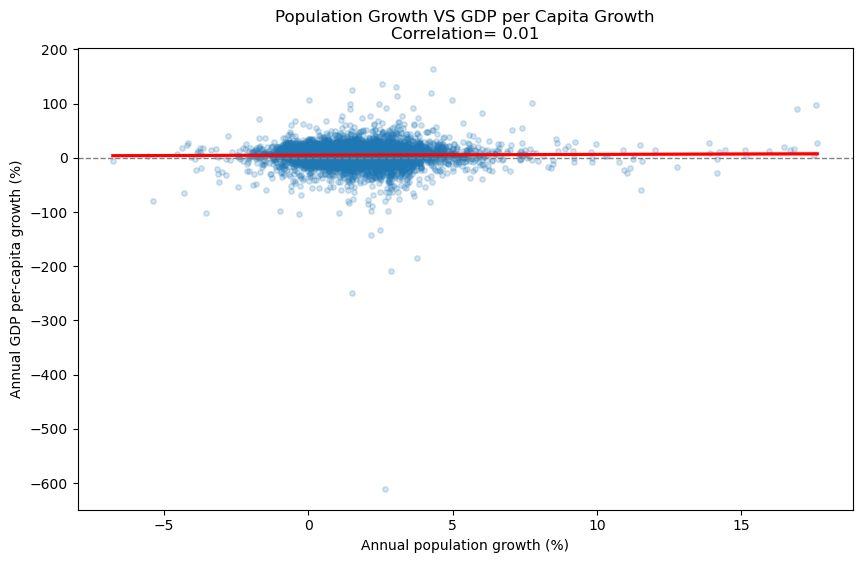

In [33]:
#Visual 1
correlation = growth_plot[["population_growth", "gdp_growth"]].corr().iloc[0, 1]

plt.figure(figsize=(10, 6))

sns.regplot(data=growth_plot,
           x="population_growth",
           y="gdp_growth",
           scatter_kws={"alpha": 0.20, "s": 15}, 
           line_kws={"color":"red"})

plt.title(f"Population Growth VS GDP per Capita Growth\n"
         f"Correlation= {correlation:.2f}")

plt.xlabel("Annual population growth (%)")
plt.ylabel("Annual GDP per-capita growth (%)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

*Answer to research question:* - The correlation coefficient of 0.01 indicates a negligible positive linear relationship between population growth and GDP growth. Population growth alone does not appear to be strongly associated with GDP growth in this dataset.

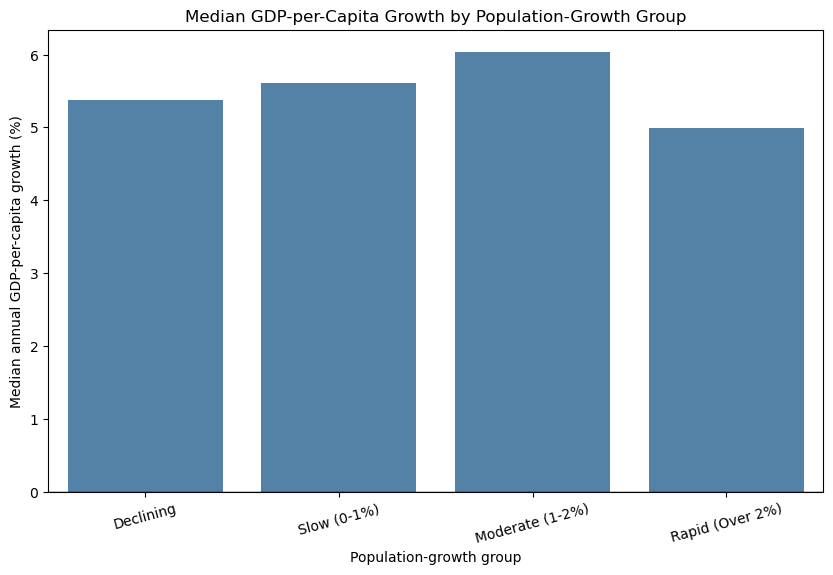

In [34]:
#Visual 2
growth_plot["population_growth_group"] = pd.cut(
    growth_plot["population_growth"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels = [
        "Declining",
        "Slow (0-1%)",
        "Moderate (1-2%)",
        "Rapid (Over 2%)"
    ]
)

growth_summary = (growth_plot.groupby(
    "population_growth_group", 
    observed = True)["gdp_growth"].median().reset_index())

plt.figure(figsize=(10, 6))

sns.barplot(
    data = growth_summary,
    x="population_growth_group",
    y="gdp_growth",
    color="steelblue"
)

plt.title("Median GDP-per-Capita Growth by Population-Growth Group")
plt.xlabel("Population-growth group")
plt.ylabel("Median annual GDP-per-capita growth (%)")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=15)
plt.show()

*Answer to research question:* GDP-per-capita growth increases from the declining group to the moderate-growth group, but falls for the rapid-growth group. This suggests that moderate population growth is associated with stronger economic growth in this dataset, while very rapid growth is not. However, the differences are relatively small and do not demonstrate causation.

### **5.2:** Reflection

*Answer:* - The data-wrangling process successfully combined population and GDP-per-capita data, but missing GDP observations reduced coverage for some countries and years. With more time, I would investigate the missing-data patterns and validate unusual values against additional authoritative sources instead of simply excluding incomplete records. I would also compare GDP per capita in constant dollars and examine regional differences to reduce the effects of inflation and uncover relationships hidden in the global analysis.